<a href="https://colab.research.google.com/github/mlelarge/graph_neural_net/blob/main/plot_accuracy_regular.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook pour l'EA
## Noé Colomban - Aymen Haouas - Romain Maurel - Amine Saadi

Nous allons regrouper ici les résultats du rapport de projet. Le début du notebook est une adaptation du notebook fourni dans le GitHub associé au projet.

In [25]:
import os
from pathlib import Path
import math
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
from models import get_model, get_model_gen
from toolbox.losses import triplet_loss
from toolbox import metrics
from loaders.data_generator import QAP_Generator
from loaders.siamese_loaders import siamese_loader
from toolbox.metrics import all_losses_acc, accuracy_linear_assignment
from toolbox.utils import check_dir

In [2]:
#Fonctions déjà présentes sur le notebook initial. Nous avons ajouté un paramètre 'MGNN':bool pour prendre en compte ce modèle.

from project.importation import get_device_config, load_model, creat_args, acc_2_error, compute_all, compute_quant

# 2. MGNN vs FGNN

Cette cellule va chercher le modèle FGNN pré-entraîné.

In [3]:
import requests
config_url = 'https://github.com/mlelarge/graph_neural_net/releases/download/QAP/config.json'
model_url = 'https://github.com/mlelarge/graph_neural_net/releases/download/QAP/model_best.pth.tar'
cwd = os.getcwd()
downloads = os.path.join(cwd, 'downloads')
check_dir(downloads)

r = requests.get(config_url)
with open(cwd+'/downloads/config.json', 'wb') as f:
    f.write(r.content)

r = requests.get(model_url)
with open(cwd+'/downloads/model_best.pth.tar', 'wb') as f:
    f.write(r.content)

Notre MGNN codé est dans le dossiez "models/mgnn_better"

In [ ]:
model_path = cwd+'/downloads/'
config_model, device = get_device_config(model_path)
model = load_model(model_path,config_model,device)
criterion = triplet_loss()


#MGNN codé

model_path_MGNN = cwd+"\\trained_models\\mgnn_better\\"
config_model_MGNN, device = get_device_config(model_path_MGNN)
model_MGNN = load_model(model_path_MGNN,config_model_MGNN,device, MGNN=True)
model_MGNN.eval()
criterion = triplet_loss()

Fetching model Siamese_Model - Simple_Node_Embedding 
Fetching model mgnn siamese - (rs_node  embedding if fgnn)


In [ ]:
args,deg  = creat_args(config_model, num_ex=500)

args_MGNN, deg_MGNN = creat_args(config_model_MGNN, num_ex=500, MGNN=True)

graphs with 50 vertices and average degree 10.0


In [ ]:
num = 23
list_noise = np.linspace(0, 0.22, num=num)

# Inference

The cell below will create dataset of graphs with various level of noise if they do not exist, otherwise it will only read them.

In [35]:
ROOT_DIR = Path.home()
path_dataset = os.path.join(ROOT_DIR, 'data\\')

all_l, all_a = compute_all(criterion, device, list_noise,args,path_dataset,model)
all_l_MGNN, all_a_MGNN = compute_all(criterion, device, list_noise,args_MGNN,path_dataset,model_MGNN)

Reading dataset at C:\Users\ordinateur\data\QAP_Regular_ErdosRenyi_100_50_1.0_0.0_0.2\test.pkl
Creating dataset at C:\Users\ordinateur\data\QAP_Regular_ErdosRenyi_100_50_1.0_0.024444444444444446_0.2\test.pkl


100%|██████████| 100/100 [00:01<00:00, 55.09it/s]


Saving dataset at C:\Users\ordinateur\data\QAP_Regular_ErdosRenyi_100_50_1.0_0.024444444444444446_0.2\test.pkl
Creating dataset at C:\Users\ordinateur\data\QAP_Regular_ErdosRenyi_100_50_1.0_0.024444444444444446_0.2\test_dgl.pkl
Converting data to DGL format


100%|██████████| 100/100 [00:00<00:00, 118.78it/s]


Conversion ended.
Saving dataset at C:\Users\ordinateur\data\QAP_Regular_ErdosRenyi_100_50_1.0_0.024444444444444446_0.2\test_dgl.pkl
Creating dataset at C:\Users\ordinateur\data\QAP_Regular_ErdosRenyi_100_50_1.0_0.04888888888888889_0.2\test.pkl


...

Conversion ended.
Saving dataset at C:\Users\ordinateur\data\QAP_ErdosRenyi_ErdosRenyi_100_50_1.0_0.19555555555555557_0.2\test_dgl.pkl
Creating dataset at C:\Users\ordinateur\data\QAP_ErdosRenyi_ErdosRenyi_100_50_1.0_0.22_0.2\test.pkl


100%|██████████| 100/100 [00:01<00:00, 76.53it/s]


Saving dataset at C:\Users\ordinateur\data\QAP_ErdosRenyi_ErdosRenyi_100_50_1.0_0.22_0.2\test.pkl
Creating dataset at C:\Users\ordinateur\data\QAP_ErdosRenyi_ErdosRenyi_100_50_1.0_0.22_0.2\test_dgl.pkl
Converting data to DGL format


100%|██████████| 100/100 [00:00<00:00, 145.86it/s]


Conversion ended.
Saving dataset at C:\Users\ordinateur\data\QAP_ErdosRenyi_ErdosRenyi_100_50_1.0_0.22_0.2\test_dgl.pkl


# Results

The FGNN has been trained with regular graphs with $50$ vertices, average degree $10$ and noise level $0.15$. The accuracy below is the fraction of matched vertices between two noisy versions of a given graph at various level of noise.

In [36]:
quant_low=0.1
quant_up=0.9
mc_50, q50 = compute_quant(all_a,quant_low=quant_low,quant_up=quant_up)
mc_50_MGNN, q50_MGNN = compute_quant(all_a_MGNN,quant_low=quant_low,quant_up=quant_up)

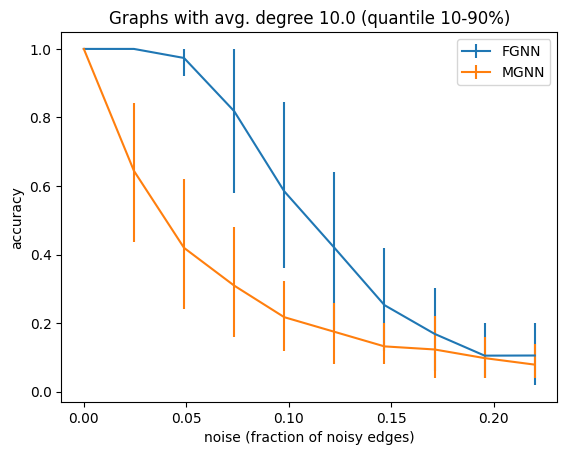

In [37]:
error_50 = np.abs(acc_2_error(mc_50,q50))
error_50_MGNN = np.abs(acc_2_error(mc_50_MGNN,q50_MGNN))


plt.errorbar(list_noise,mc_50,yerr=error_50.T,label='FGNN')
plt.errorbar(list_noise,mc_50_MGNN,yerr=error_50_MGNN.T,label='MGNN')
plt.xlabel('noise (fraction of noisy edges)')
plt.ylabel('accuracy')
plt.title(f'Graphs with avg. degree {deg} (quantile {int(100*quant_low)}-{int(100*quant_up)}%)')
plt.legend()
plt.show()



## Graphes de Shrikhande vs Rook

Le MGNN doit normalement échouer sur ce type de graphes particuliers, car incapable de différencier certains graphes. Le FGNN peut les différencier. Nous allons tester cela sans réentraîner les modèles, car la différence de prédiction pour le MGNN devrait être tout de même très inférieure.

In [38]:
from project.comparison import build_rooks, build_shrikhande

In [ ]:
args_fgnn = {
    'arch_gnn': 'fgnn',           
    'arch_load': 'siamese',    #siamois
    'embedding': 'edge',  #En 'node', le fgnn est aussi incapable de différencier les deux
    'original_features_num': 2,   
    'num_blocks': 2,              
    'dim_features': 16,           
    'depth_of_mlp': 3,            
    'input_embed': False          
}
model_FGNN = get_model_gen(args_fgnn).to(device)

import networkx as nx

A_shrik = build_shrikhande()
A_rook = build_rooks()

# Paire A =~ (Shrikhande, Shrikhande)
X_pair_A = torch.zeros((1, 2, 16, 16, 2), dtype=torch.float32)
X_pair_A[0, 0, :, :, 0] = torch.tensor(A_shrik)
X_pair_A[0, 0, :, :, 1] = torch.eye(16)
X_pair_A[0, 1, :, :, 0] = torch.tensor(A_shrik)
X_pair_A[0, 1, :, :, 1] = torch.eye(16)

# Paire B =~ (Shrikhande, Rook)
X_pair_B = torch.zeros((1, 2, 16, 16, 2), dtype=torch.float32)
X_pair_B[0, 0, :, :, 0] = torch.tensor(A_shrik)
X_pair_B[0, 0, :, :, 1] = torch.eye(16)
X_pair_B[0, 1, :, :, 0] = torch.tensor(A_rook)
X_pair_B[0, 1, :, :, 1] = torch.eye(16)

X_pair_A = X_pair_A.to(device)
X_pair_B = X_pair_B.to(device)

#Evaluation
model_MGNN.eval()
model_FGNN.eval()

print("Test Siamese")
with torch.no_grad():
    #Sorties du Siamois MGNN
    S_mgnn_A = model_MGNN(X_pair_A)
    S_mgnn_B = model_MGNN(X_pair_B)

    #Sorties du Siamois FGNN
    S_fgnn_A = model_FGNN(X_pair_A)
    S_fgnn_B = model_FGNN(X_pair_B)

# On utilise la norme pour voir à quel point les matrices d'adjacence diffèrent
diff_mgnn = torch.norm(S_mgnn_A - S_mgnn_B).item()
diff_fgnn = torch.norm(S_fgnn_A - S_fgnn_B).item()

print(f"Différence entre les prédictions (S_A vs S_B) pour le MGNN : {diff_mgnn:.10g}")
print(f"Différence entre les prédictions (S_A vs S_B) pour le FGNN : {diff_fgnn:.10g}")

Fetching model fgnn siamese - (edge  embedding if fgnn)
Test Siamese
Différence entre les prédictions (S_A vs S_B) pour le MGNN : 0.005393242463
Différence entre les prédictions (S_A vs S_B) pour le FGNN : 0.1033889428


# 3. Évaluation étendue et analyse de robustesse

## Model Summary & Parameter Count

Let's inspect the architecture of the pretrained FGNN and count the number of trainable parameters.

In [61]:
# FGNN Model architecture
print("=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)
print(model)
print("\n" + "=" * 60)
print("PARAMETER COUNT")
print("=" * 60)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nConfig: {config_model['arch']}")
print(f"  - num_blocks: {config_model['arch']['num_blocks']}")
print(f"  - in_features: {config_model['arch']['in_features']}")
print(f"  - out_features: {config_model['arch']['out_features']}")
print(f"  - depth_of_mlp: {config_model['arch']['depth_of_mlp']}")
print(f"  - Device: {device}")

MODEL ARCHITECTURE
Siamese_Model(
  (node_embedder): Simple_Node_Embedding(
    (base_model): BaseModel(
      (reg_blocks): ModuleList(
        (0): RegularBlock(
          (mlp1): MlpBlock(
            (convs): ModuleList(
              (0): Conv2d(2, 64, kernel_size=(1, 1), stride=(1, 1))
              (1-2): 2 x Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
            )
          )
          (mlp2): MlpBlock(
            (convs): ModuleList(
              (0): Conv2d(2, 64, kernel_size=(1, 1), stride=(1, 1))
              (1-2): 2 x Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
            )
          )
          (mlp3): MlpBlock(
            (convs): ModuleList(
              (0): Conv2d(66, 64, kernel_size=(1, 1), stride=(1, 1))
              (1-2): 2 x Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
            )
          )
          (last_layer): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
        )
        (1): RegularBlock(
          (mlp1): MlpBlock(
      

IndexError: index 11 is out of bounds for axis 0 with size 10

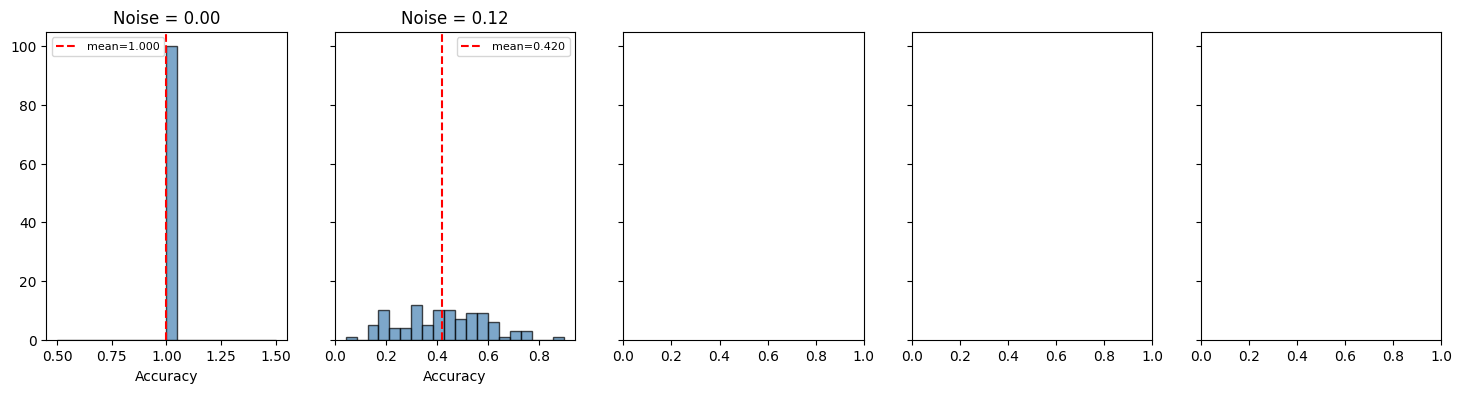

In [62]:
# Pick a few representative noise levels: low, medium (training noise), high
noise_indices = [0, 5, 11, 15, 22]  # indices into list_noise
fig, axes = plt.subplots(1, len(noise_indices), figsize=(18, 4), sharey=True)

for ax, idx in zip(axes, noise_indices):
    noise_val = list_noise[idx]
    acc_data = all_a[idx]
    ax.hist(acc_data, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(np.mean(acc_data), color='red', linestyle='--', label=f'mean={np.mean(acc_data):.3f}')
    ax.set_title(f'Noise = {noise_val:.2f}')
    ax.set_xlabel('Accuracy')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Count')
fig.suptitle('Distribution of Per-Graph Accuracy at Various Noise Levels', fontsize=14)
plt.tight_layout()
plt.show()

# 3. Hungarian Algorithm vs Greedy Argmax Decoding

The model outputs a soft assignment matrix. We can decode it in two ways:
- **Hungarian algorithm** (**linear_sum_assignment**): optimal bipartite matching.
- **Greedy argmax**: simply take **argmax** per row, faster but suboptimal.

Let's compare them to see which method matters.

In [63]:
from toolbox.metrics import accuracy_max
from project.importation import compute_all_with_metric

all_a_argmax = compute_all_with_metric(list_noise, args, path_dataset, model, criterion, device, accuracy_max)

mc_50_argmax, q50_argmax = compute_quant(all_a_argmax, quant_low=quant_low, quant_up=quant_up)

Reading dataset at C:\Users\ordinateur\data\QAP_Regular_ErdosRenyi_100_50_1.0_0.0_0.2\test.pkl
Reading dataset at C:\Users\ordinateur\data\QAP_Regular_ErdosRenyi_100_50_1.0_0.024444444444444446_0.2\test.pkl
Reading dataset at C:\Users\ordinateur\data\QAP_Regular_ErdosRenyi_100_50_1.0_0.04888888888888889_0.2\test.pkl
Reading dataset at C:\Users\ordinateur\data\QAP_Regular_ErdosRenyi_100_50_1.0_0.07333333333333333_0.2\test.pkl
Reading dataset at C:\Users\ordinateur\data\QAP_Regular_ErdosRenyi_100_50_1.0_0.09777777777777778_0.2\test.pkl
Reading dataset at C:\Users\ordinateur\data\QAP_Regular_ErdosRenyi_100_50_1.0_0.12222222222222223_0.2\test.pkl
Reading dataset at C:\Users\ordinateur\data\QAP_Regular_ErdosRenyi_100_50_1.0_0.14666666666666667_0.2\test.pkl
Reading dataset at C:\Users\ordinateur\data\QAP_Regular_ErdosRenyi_100_50_1.0_0.17111111111111113_0.2\test.pkl
Reading dataset at C:\Users\ordinateur\data\QAP_Regular_ErdosRenyi_100_50_1.0_0.19555555555555557_0.2\test.pkl
Reading dataset 

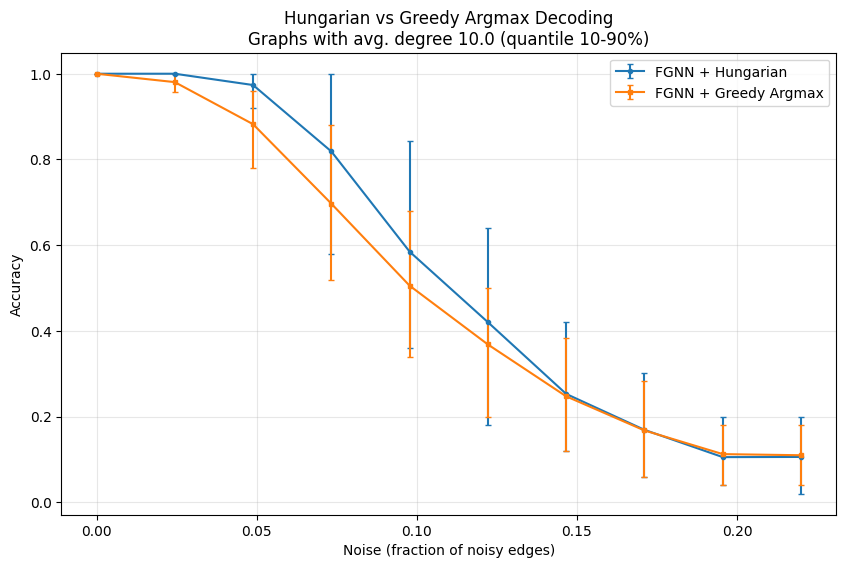


Accuracy gap (Hungarian - Argmax):
  Noise=0.00: Hungarian=1.000, Argmax=1.000, Gap=0.000
  Noise=0.10: Hungarian=0.585, Argmax=0.505, Gap=0.079
  Noise=0.20: Hungarian=0.105, Argmax=0.112, Gap=-0.007


In [64]:
# Plot comparison: Hungarian vs Argmax
error_hungarian = abs(acc_2_error(mc_50, q50))
error_argmax = abs(acc_2_error(mc_50_argmax, q50_argmax))

plt.figure(figsize=(10, 6))
plt.errorbar(list_noise, mc_50, yerr=error_hungarian.T, label='FGNN + Hungarian', marker='o', markersize=3, capsize=2)
plt.errorbar(list_noise, mc_50_argmax, yerr=error_argmax.T, label='FGNN + Greedy Argmax', marker='s', markersize=3, capsize=2)
plt.xlabel('Noise (fraction of noisy edges)')
plt.ylabel('Accuracy')
plt.title(f'Hungarian vs Greedy Argmax Decoding\nGraphs with avg. degree {deg} (quantile {int(100*quant_low)}-{int(100*quant_up)}%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print the gap
print("\nAccuracy gap (Hungarian - Argmax):")
for i in range(0, len(list_noise), 4):
    print(f"  Noise={list_noise[i]:.2f}: Hungarian={mc_50[i]:.3f}, Argmax={mc_50_argmax[i]:.3f}, Gap={mc_50[i]-mc_50_argmax[i]:.3f}")

## Random Baseline Comparison

How much better is the FGNN compared to a random permutation? 
For a graph with $n$ vertices, a random matching has expected accuracy $1/n$.

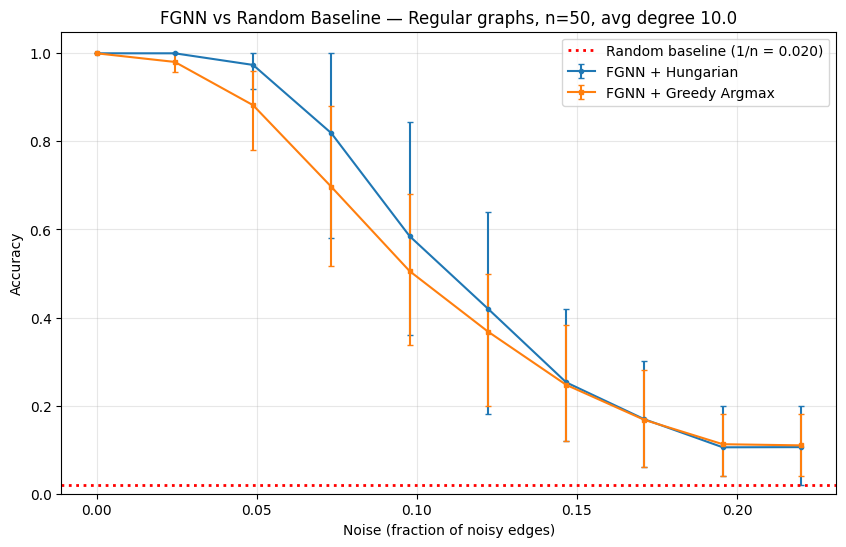


Improvement factor over random baseline (1/n = 0.0200):
  Noise=0.00: FGNN acc=1.000, improvement = 50.0x
  Noise=0.10: FGNN acc=0.585, improvement = 29.2x
  Noise=0.20: FGNN acc=0.105, improvement = 5.3x


In [65]:
n_vertices = args['n_vertices']
random_baseline = 1.0 / n_vertices  # Expected accuracy of random matching

plt.figure(figsize=(10, 6))
plt.errorbar(list_noise, mc_50, yerr=error_hungarian.T, label='FGNN + Hungarian', marker='o', markersize=3, capsize=2)
plt.errorbar(list_noise, mc_50_argmax, yerr=error_argmax.T, label='FGNN + Greedy Argmax', marker='s', markersize=3, capsize=2)
plt.axhline(y=random_baseline, color='red', linestyle=':', linewidth=2, label=f'Random baseline (1/n = {random_baseline:.3f})')
plt.xlabel('Noise (fraction of noisy edges)')
plt.ylabel('Accuracy')
plt.title(f'FGNN vs Random Baseline — Regular graphs, n={n_vertices}, avg degree {deg}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(bottom=0)
plt.show()

# Compute improvement factor over random
print(f"\nImprovement factor over random baseline (1/n = {random_baseline:.4f}):")
for i in range(0, len(list_noise), 4):
    factor = mc_50[i] / random_baseline
    print(f"  Noise={list_noise[i]:.2f}: FGNN acc={mc_50[i]:.3f}, improvement = {factor:.1f}x")

## Generalization to Different Graph Types

The model was trained on Regular graphs. 
We will test how well it generalizes to **Erdos-Renyi** and **Barabasi-Albert** graphs, in order to evaluate out-of-distribution robustness.

In [66]:
import copy

# We'll test fewer noise points for speed
num_gen = 11
list_noise_gen = np.linspace(0, 0.22, num=num_gen)
num_ex_gen = 500  # fewer examples for faster evaluation

graph_types = {
    'Regular': {'generative_model': 'Regular', 'noise_model': 'ErdosRenyi'},
    'Erdos-Renyi': {'generative_model': 'ErdosRenyi', 'noise_model': 'ErdosRenyi'},
    'Barabasi-Albert': {'generative_model': 'BarabasiAlbert', 'noise_model': 'ErdosRenyi'},
}

results_by_type = {}

for gtype, gparams in graph_types.items():
    print(f"\n{'='*40}")
    print(f"Testing on {gtype} graphs...")
    print(f"{'='*40}")
    args_gen = copy.deepcopy(args)
    args_gen['generative_model'] = gparams['generative_model']
    args_gen['noise_model'] = gparams['noise_model']
    args_gen['num_examples_test'] = num_ex_gen
    
    num_batches = math.ceil(args_gen['num_examples_test'] / 50)
    all_acc_gen = np.zeros((num_gen, num_ex_gen))
    
    for i, noise_val in enumerate(list_noise_gen):
        args_gen['noise'] = noise_val
        gene_test = QAP_Generator('test', args_gen, path_dataset)
        gene_test.load_dataset()
        test_loader = siamese_loader(gene_test, 50, gene_test.constant_n_vertices)
        _, all_acc_gen[i, :] = all_losses_acc(test_loader, model, criterion, device,
                                               eval_score=accuracy_linear_assignment)
    
    mean_acc = np.mean(all_acc_gen, 1)
    results_by_type[gtype] = mean_acc
    print(f"  Mean accuracy at noise=0: {mean_acc[0]:.3f}")

print("\nDone!")


Testing on Regular graphs...
Creating dataset at C:\Users\ordinateur\data\QAP_Regular_ErdosRenyi_500_50_1.0_0.0_0.2\test.pkl


  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:03<00:00, 130.54it/s]


Saving dataset at C:\Users\ordinateur\data\QAP_Regular_ErdosRenyi_500_50_1.0_0.0_0.2\test.pkl
Creating dataset at C:\Users\ordinateur\data\QAP_Regular_ErdosRenyi_500_50_1.0_0.0_0.2\test_dgl.pkl
Converting data to DGL format


100%|██████████| 500/500 [00:03<00:00, 139.42it/s]


...

Conversion ended.
Saving dataset at C:\Users\ordinateur\data\QAP_BarabasiAlbert_ErdosRenyi_500_50_1.0_0.19799999999999998_0.2\test_dgl.pkl
Creating dataset at C:\Users\ordinateur\data\QAP_BarabasiAlbert_ErdosRenyi_500_50_1.0_0.22_0.2\test.pkl


100%|██████████| 500/500 [00:07<00:00, 70.85it/s] 


Saving dataset at C:\Users\ordinateur\data\QAP_BarabasiAlbert_ErdosRenyi_500_50_1.0_0.22_0.2\test.pkl
Creating dataset at C:\Users\ordinateur\data\QAP_BarabasiAlbert_ErdosRenyi_500_50_1.0_0.22_0.2\test_dgl.pkl
Converting data to DGL format


100%|██████████| 500/500 [00:05<00:00, 95.21it/s] 


Conversion ended.
Saving dataset at C:\Users\ordinateur\data\QAP_BarabasiAlbert_ErdosRenyi_500_50_1.0_0.22_0.2\test_dgl.pkl
  Mean accuracy at noise=0: 1.000

Done!


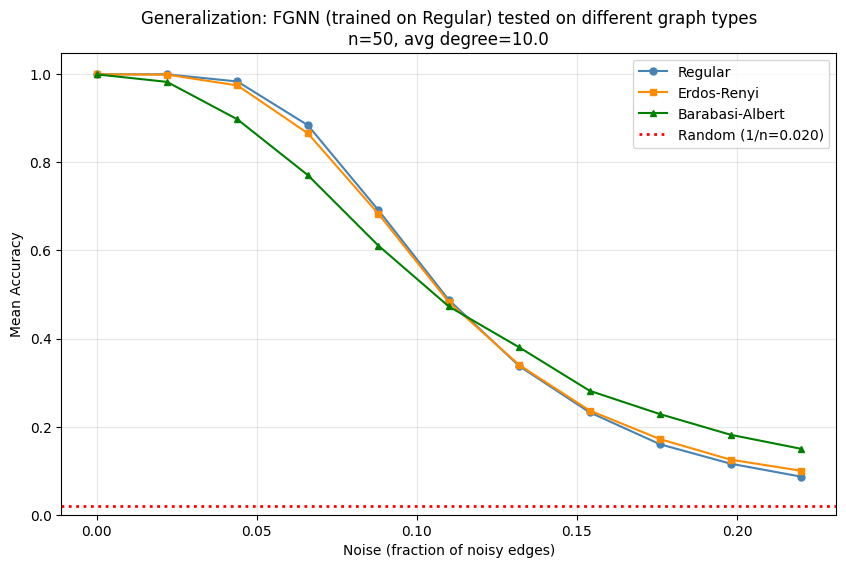

In [67]:
# Plot generalization results
plt.figure(figsize=(10, 6))
markers = ['o', 's', '^']
colors = ['steelblue', 'darkorange', 'green']

for (gtype, mean_acc), marker, color in zip(results_by_type.items(), markers, colors):
    plt.plot(list_noise_gen, mean_acc, marker=marker, markersize=5, label=gtype, color=color)

plt.axhline(y=random_baseline, color='red', linestyle=':', linewidth=2, label=f'Random (1/n={random_baseline:.3f})')
plt.xlabel('Noise (fraction of noisy edges)')
plt.ylabel('Mean Accuracy')
plt.title(f'Generalization: FGNN (trained on Regular) tested on different graph types\nn={n_vertices}, avg degree={deg}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(bottom=0)
plt.show()

## Generalization to Different Graph Sizes

The model was trained on graphs with $n=50$ vertices. A key advantage of GNNs is size-generalization. Let's test the model on graphs with **20, 50, and 100 vertices** while keeping the same edge density.

In [ ]:
graph_sizes = [20, 50, 100]
num_size = 11
list_noise_size = np.linspace(0, 0.22, num=num_size)
num_ex_size = 500

results_by_size = {}

for n in graph_sizes:
    print(f"\n{'='*40}")
    print(f"Testing with n_vertices = {n}...")
    print(f"{'='*40}")
    args_size = copy.deepcopy(args)
    args_size['n_vertices'] = n
    args_size['num_examples_test'] = num_ex_size
    
    all_acc_size = np.zeros((num_size, num_ex_size))
    
    for i, noise_val in enumerate(list_noise_size):
        args_size['noise'] = noise_val
        gene_test = QAP_Generator('test', args_size, path_dataset)
        gene_test.load_dataset()
        test_loader = siamese_loader(gene_test, 50, gene_test.constant_n_vertices)
        _, all_acc_size[i, :] = all_losses_acc(test_loader, model, criterion, device,
                                                eval_score=accuracy_linear_assignment)
    
    mean_acc = np.mean(all_acc_size, 1)
    results_by_size[n] = mean_acc
    avg_deg = n * args_size['edge_density']
    print(f"  n={n}, avg degree={avg_deg:.1f}, accuracy at noise=0: {mean_acc[0]:.3f}")

print("\nDone!")


Testing with n_vertices = 20...
Creating dataset at C:\Users\ordinateur\data\QAP_Regular_ErdosRenyi_500_20_1.0_0.0_0.2\test.pkl


100%|██████████| 500/500 [00:03<00:00, 135.08it/s]


Saving dataset at C:\Users\ordinateur\data\QAP_Regular_ErdosRenyi_500_20_1.0_0.0_0.2\test.pkl
Creating dataset at C:\Users\ordinateur\data\QAP_Regular_ErdosRenyi_500_20_1.0_0.0_0.2\test_dgl.pkl
Converting data to DGL format


100%|██████████| 500/500 [00:02<00:00, 206.05it/s]


Conversion ended.
Saving dataset at C:\Users\ordinateur\data\QAP_Regular_ErdosRenyi_500_20_1.0_0.0_0.2\test_dgl.pkl
Creating dataset at C:\Users\ordinateur\data\QAP_Regular_ErdosRenyi_500_20_1.0_0.022_0.2\test.pkl


...

Conversion ended.
Saving dataset at C:\Users\ordinateur\data\QAP_Regular_ErdosRenyi_500_100_1.0_0.10999999999999999_0.2\test_dgl.pkl
Creating dataset at C:\Users\ordinateur\data\QAP_Regular_ErdosRenyi_500_100_1.0_0.132_0.2\test.pkl


100%|██████████| 500/500 [00:13<00:00, 37.34it/s]


Saving dataset at C:\Users\ordinateur\data\QAP_Regular_ErdosRenyi_500_100_1.0_0.132_0.2\test.pkl
Creating dataset at C:\Users\ordinateur\data\QAP_Regular_ErdosRenyi_500_100_1.0_0.132_0.2\test_dgl.pkl
Converting data to DGL format


100%|██████████| 500/500 [00:09<00:00, 52.37it/s]


Conversion ended.
Saving dataset at C:\Users\ordinateur\data\QAP_Regular_ErdosRenyi_500_100_1.0_0.132_0.2\test_dgl.pkl


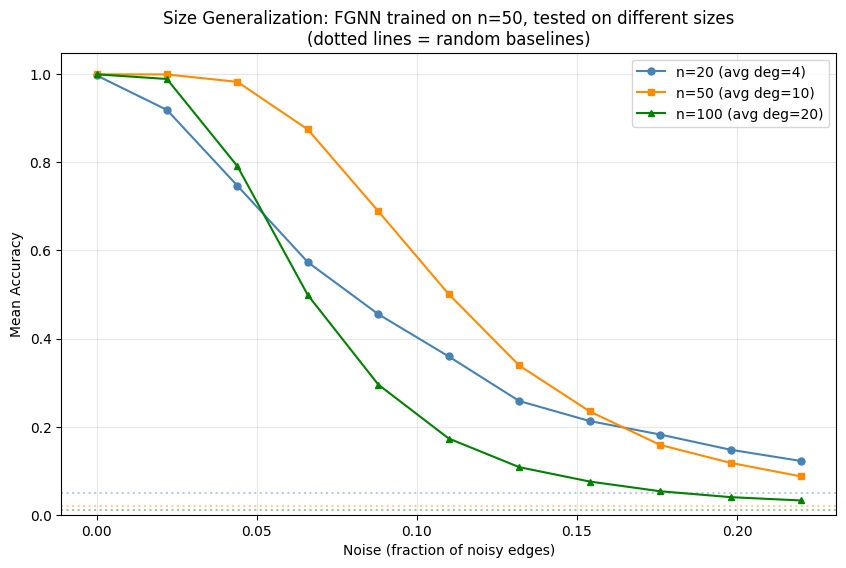

In [ ]:
# Plot size generalization
plt.figure(figsize=(10, 6))
markers = ['o', 's', '^']
colors = ['steelblue', 'darkorange', 'green']

for (n, mean_acc), marker, color in zip(results_by_size.items(), markers, colors):
    avg_deg = n * args['edge_density']
    plt.plot(list_noise_size, mean_acc, marker=marker, markersize=5,
             label=f'n={n} (avg deg={avg_deg:.0f})', color=color)
    # Show random baseline for each size
    plt.axhline(y=1.0/n, color=color, linestyle=':', alpha=0.4)

plt.xlabel('Noise (fraction of noisy edges)')
plt.ylabel('Mean Accuracy')
plt.title('Size Generalization: FGNN trained on n=50, tested on different sizes\n(dotted lines = random baselines)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(bottom=0)
plt.show()

## Visualizing the Similarity Matrix

Now we will look at what the model outputs: the similarity matrix for a single graph pair. 
A perfect prediction shows a strong diagonal pattern.

Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_10_50_1.0_0.0_0.2/test.pkl
Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_10_50_1.0_0.05_0.2/test.pkl
Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_10_50_1.0_0.15_0.2/test.pkl
Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_10_50_1.0_0.22_0.2/test.pkl


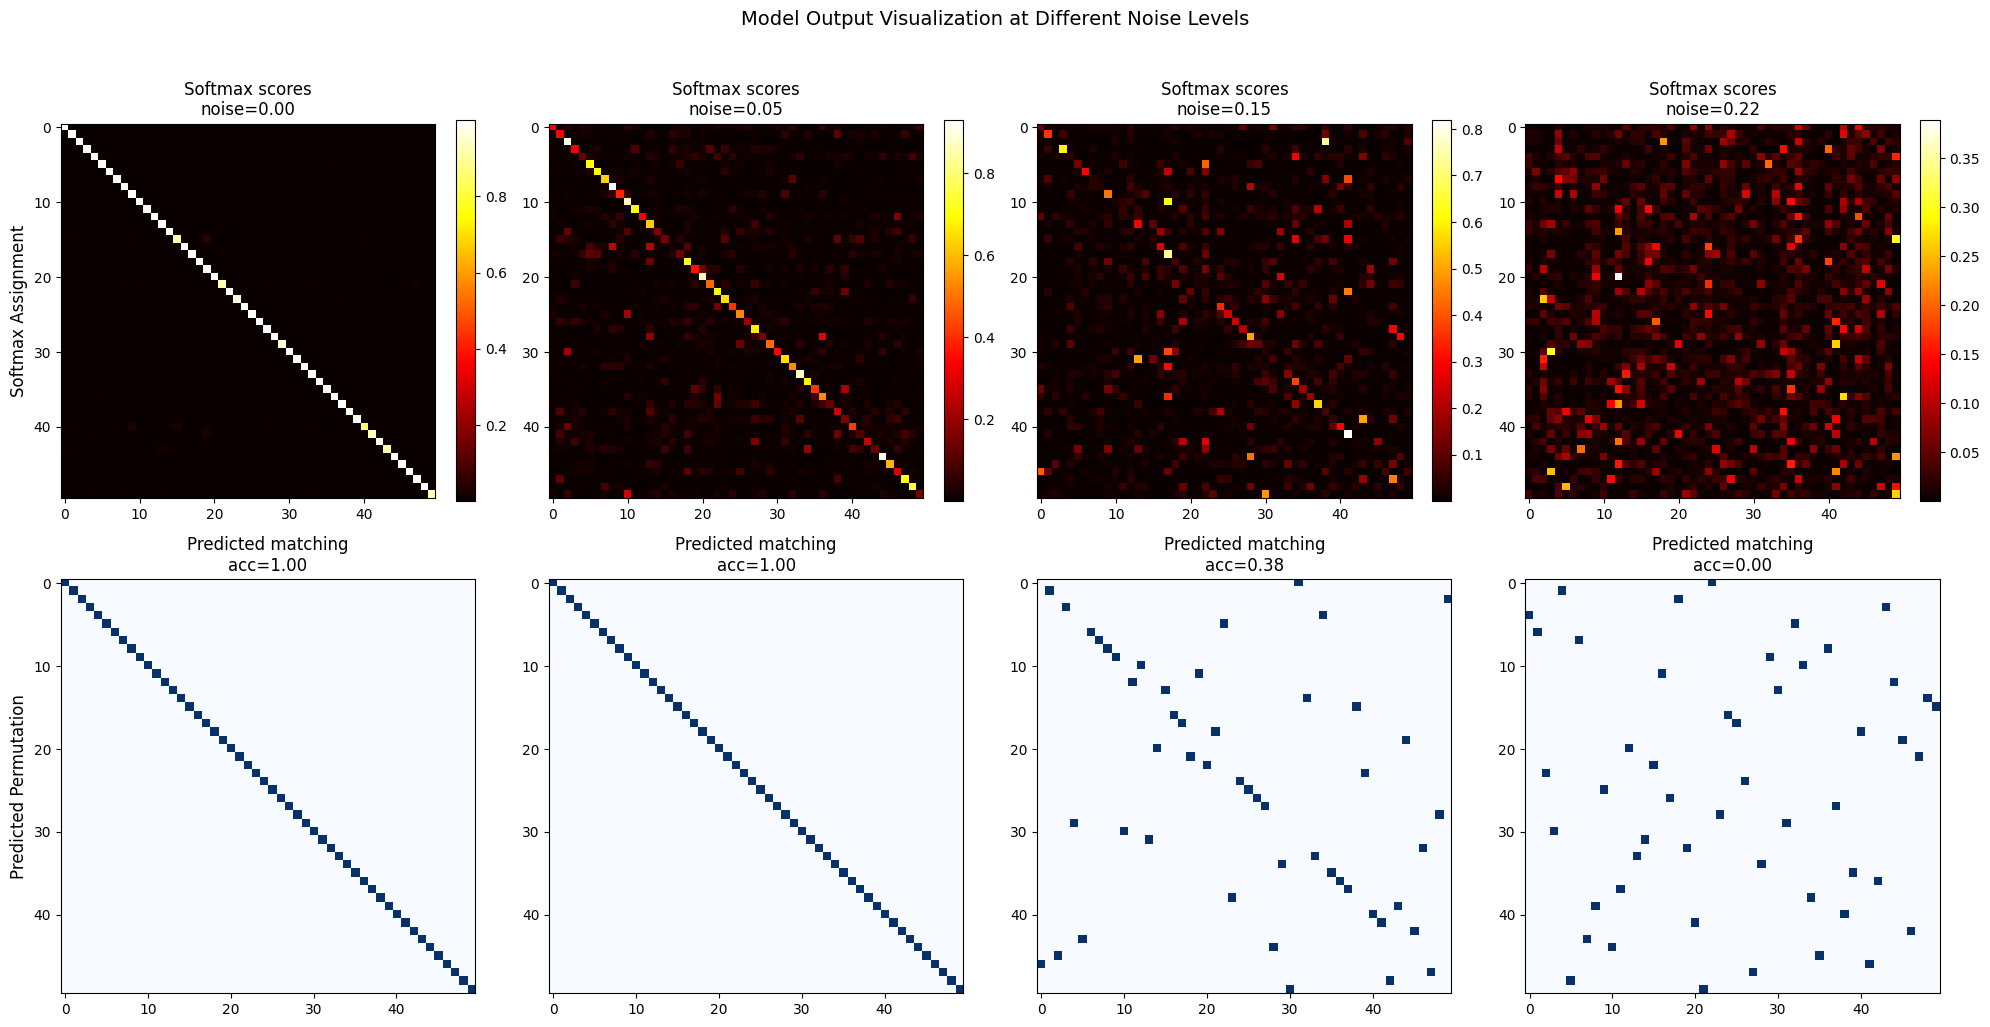

In [ ]:
from scipy.optimize import linear_sum_assignment

# Generate one example at low noise and one at high noise
noise_levels_viz = [0.0, 0.05, 0.15, 0.22]
fig, axes = plt.subplots(2, len(noise_levels_viz), figsize=(20, 10))

for col, noise_val in enumerate(noise_levels_viz):
    args_viz = copy.deepcopy(args)
    args_viz['noise'] = noise_val
    args_viz['num_examples_test'] = 10
    gene_viz = QAP_Generator('test', args_viz, path_dataset)
    gene_viz.load_dataset()
    
    # Get a single example
    data, target = gene_viz[0]
    data_batch = data.unsqueeze(0).to(device)  # add batch dim
    
    with torch.no_grad():
        raw_scores = model(data_batch)
    
    # Raw scores
    scores_np = raw_scores[0].cpu().numpy()
    # Softmax scores
    soft_scores = torch.softmax(raw_scores, dim=-1)[0].cpu().numpy()
    
    # Compute matching
    cost = -torch.log_softmax(raw_scores, -1)[0].cpu().numpy()
    _, preds = linear_sum_assignment(cost)
    n = len(preds)
    acc = np.sum(preds == np.arange(n)) / n
    
    # Plot softmax scores
    im1 = axes[0, col].imshow(soft_scores, cmap='hot', aspect='equal')
    axes[0, col].set_title(f'Softmax scores\nnoise={noise_val:.2f}')
    plt.colorbar(im1, ax=axes[0, col], fraction=0.046)
    
    # Plot predicted permutation matrix
    perm_matrix = np.zeros((n, n))
    perm_matrix[np.arange(n), preds] = 1
    axes[1, col].imshow(perm_matrix, cmap='Blues', aspect='equal')
    axes[1, col].set_title(f'Predicted matching\nacc={acc:.2f}')

axes[0, 0].set_ylabel('Softmax Assignment', fontsize=12)
axes[1, 0].set_ylabel('Predicted Permutation', fontsize=12)
fig.suptitle('Model Output Visualization at Different Noise Levels', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Train New Models on Different Graph Types & Compare

Let's now train our own FGNN models directly on **Erdos-Renyi** and **Barabasi-Albert** graphs, then compare all three (third is regular pretrained model).

We use a lightweight setup for speed:
- 2000 training examples (vs 20000 in the original)
- 500 validation examples
- 10 epochs
- Same architecture (2 blocks, 64-dim, depth-3 MLPs)

In [ ]:
from project.train import train_one_epoch, evaluate_accuracy, create_and_train_model

In [ ]:
# Training configuration
TRAIN_CONFIG = {
    'n_vertices': 50,
    'edge_density': 0.2,
    'training_noise': 0.15,
    'num_train': 2000,
    'num_val': 500,
    'n_epochs': 10,
    'batch_size': 32,
    'lr': 1e-3,
}

# Dictionary to hold all trained models
trained_models = {
    'Regular (pretrained)': model,  # The pretrained model from GitHub
}

# Train on Erdos-Renyi
print("=" * 60)
print("TRAINING MODEL ON ERDOS-RENYI GRAPHS")
print("=" * 60)
er_model, er_losses, er_val_acc = create_and_train_model(
    graph_type='ErdosRenyi',
    noise_model='ErdosRenyi',
    device=device,
    path_dataset=path_dataset,
    **TRAIN_CONFIG
)
trained_models['Erdos-Renyi (trained)'] = er_model

# Train on Barabasi-Albert
print("\n" + "=" * 60)
print("TRAINING MODEL ON BARABASI-ALBERT GRAPHS")
print("=" * 60)
ba_model, ba_losses, ba_val_acc = create_and_train_model(
    graph_type='BarabasiAlbert',
    noise_model='ErdosRenyi',
    device=device,
    path_dataset=path_dataset,
    **TRAIN_CONFIG
)
trained_models['Barabasi-Albert (trained)'] = ba_model

print("\n" + "=" * 60)
print("ALL MODELS READY!")
print("=" * 60)
for name in trained_models:
    print(f"  - {name}")

TRAINING MODEL ON ERDOS-RENYI GRAPHS


NameError: name 'path_dataset' is not defined

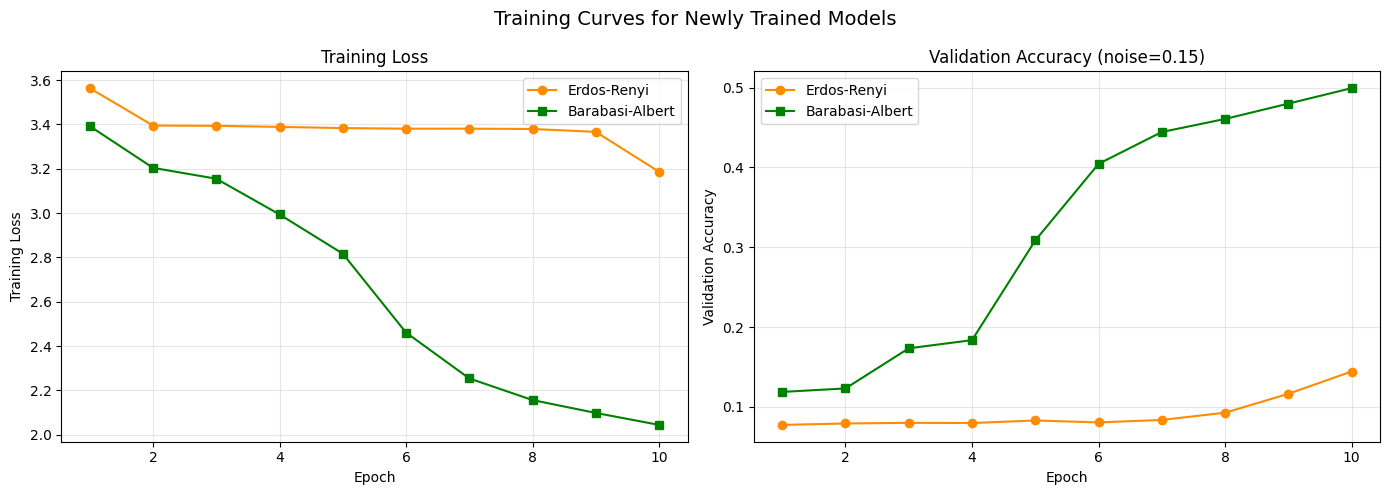

In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(range(1, len(er_losses)+1), er_losses, 'o-', label='Erdos-Renyi', color='darkorange')
axes[0].plot(range(1, len(ba_losses)+1), ba_losses, 's-', label='Barabasi-Albert', color='green')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation accuracy curves
axes[1].plot(range(1, len(er_val_acc)+1), er_val_acc, 'o-', label='Erdos-Renyi', color='darkorange')
axes[1].plot(range(1, len(ba_val_acc)+1), ba_val_acc, 's-', label='Barabasi-Albert', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Validation Accuracy (noise=0.15)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle('Training Curves for Newly Trained Models', fontsize=14)
plt.tight_layout()
plt.show()

## Cross-Evaluation: Every Model on Every Graph Type

Now an interesting experiment: We test **each model** on **each graph type**. This creates a 3×3 comparison matrix showing:

- Does a model perform best on the graph type it was trained on?
- Which model generalizes best?

In [ ]:
# Cross-evaluation: each model on each graph type
num_cross = 11
list_noise_cross = np.linspace(0, 0.22, num=num_cross)
num_ex_cross = 500

test_graph_types = ['Regular', 'ErdosRenyi', 'BarabasiAlbert']
test_graph_labels = ['Regular', 'Erdos-Renyi', 'Barabasi-Albert']

# results_cross[model_name][graph_type] = mean_acc array
results_cross = {}

for model_name, mdl in trained_models.items():
    results_cross[model_name] = {}
    mdl.eval()
    
    for gtype, glabel in zip(test_graph_types, test_graph_labels):
        print(f"Testing '{model_name}' on {glabel} graphs...")
        
        args_cross = copy.deepcopy(args)
        args_cross['generative_model'] = gtype
        args_cross['noise_model'] = 'ErdosRenyi'
        args_cross['num_examples_test'] = num_ex_cross
        
        all_acc_cross = np.zeros((num_cross, num_ex_cross))
        
        for i, noise_val in enumerate(list_noise_cross):
            args_cross['noise'] = noise_val
            gene_test = QAP_Generator('test', args_cross, path_dataset)
            gene_test.load_dataset()
            test_loader = siamese_loader(gene_test, 50, gene_test.constant_n_vertices)
            _, all_acc_cross[i, :] = all_losses_acc(
                test_loader, mdl, criterion, device,
                eval_score=accuracy_linear_assignment
            )
        
        results_cross[model_name][glabel] = np.mean(all_acc_cross, 1)

print("\nCross-evaluation complete!")

Testing 'Regular (pretrained)' on Regular graphs...
Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_50_1.0_0.0_0.2/test.pkl
Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_50_1.0_0.022_0.2/test.pkl
Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_50_1.0_0.044_0.2/test.pkl
Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_50_1.0_0.066_0.2/test.pkl
Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_50_1.0_0.088_0.2/test.pkl
Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_50_1.0_0.10999999999999999_0.2/test.pkl
Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_50_1.0_0.132_0.2/test.pkl
Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_50_1.0_0.154_0.2/test.pkl
Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_50_1.0_0.176_0.2/test.pkl
Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_50_1.0_0.197

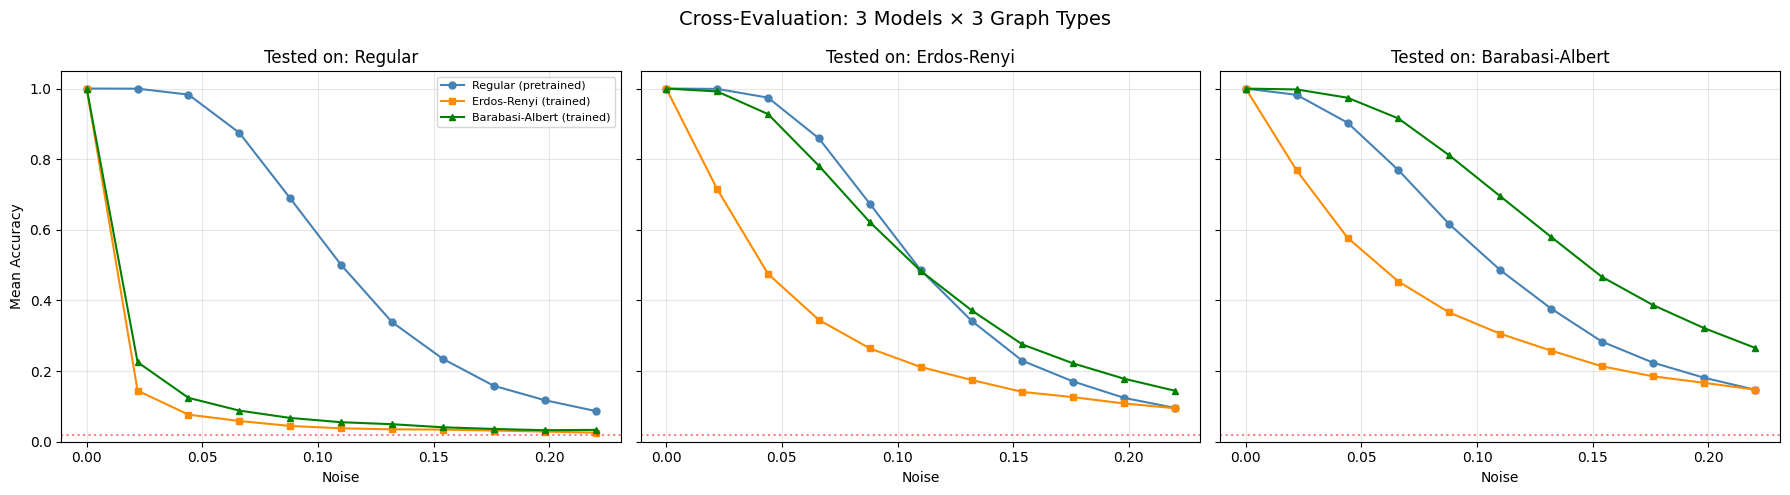

In [ ]:
# Plot: One subplot per TEST graph type, all models compared
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

model_colors = {
    'Regular (pretrained)': 'steelblue',
    'Erdos-Renyi (trained)': 'darkorange',
    'Barabasi-Albert (trained)': 'green',
}
model_markers = {
    'Regular (pretrained)': 'o',
    'Erdos-Renyi (trained)': 's',
    'Barabasi-Albert (trained)': '^',
}

for col, glabel in enumerate(test_graph_labels):
    ax = axes[col]
    for model_name in trained_models:
        acc = results_cross[model_name][glabel]
        ax.plot(list_noise_cross, acc,
                marker=model_markers[model_name], markersize=5,
                color=model_colors[model_name],
                label=model_name)
    
    ax.axhline(y=random_baseline, color='red', linestyle=':', alpha=0.5)
    ax.set_xlabel('Noise')
    ax.set_title(f'Tested on: {glabel}')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

axes[0].set_ylabel('Mean Accuracy')
axes[0].legend(fontsize=8, loc='upper right')
fig.suptitle('Cross-Evaluation: 3 Models × 3 Graph Types', fontsize=14)
plt.tight_layout()
plt.show()


Cross-Evaluation Summary (accuracy at noise = 0.11)
Tested on →                Regular  Erdos-Renyi  Barabasi-Albert
Trained on ↓                                                    
Regular (pretrained)         0.501        0.486            0.486
Erdos-Renyi (trained)        0.038        0.212            0.306
Barabasi-Albert (trained)    0.055        0.484            0.695

(Diagonal-like entries = in-distribution, off-diagonal = out-of-distribution)


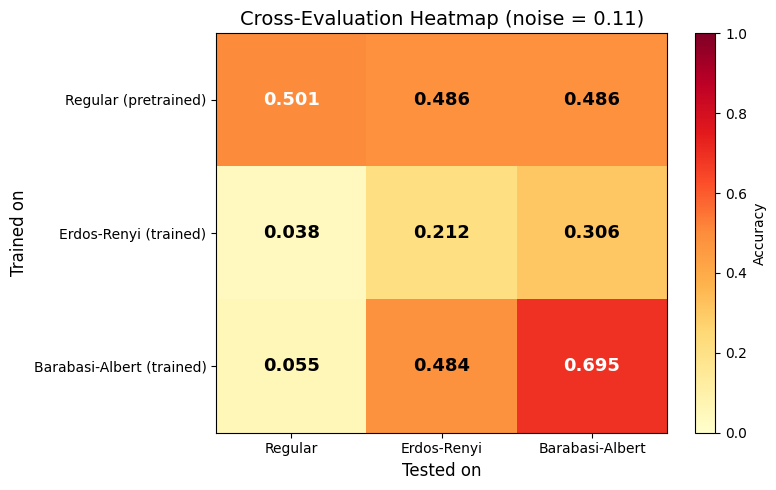

In [ ]:
# Summary heatmap: accuracy at noise=0.10 for each (model, graph_type) pair
import pandas as pd

noise_idx = 5  # index closest to noise=0.10
noise_val_summary = list_noise_cross[noise_idx]

summary_data = {}
for model_name in trained_models:
    summary_data[model_name] = {}
    for glabel in test_graph_labels:
        summary_data[model_name][glabel] = results_cross[model_name][glabel][noise_idx]

df_summary = pd.DataFrame(summary_data).T
df_summary.columns.name = 'Tested on →'
df_summary.index.name = 'Trained on ↓'

print(f"\nCross-Evaluation Summary (accuracy at noise = {noise_val_summary:.2f})")
print("=" * 60)
print(df_summary.to_string(float_format='{:.3f}'.format))
print("\n(Diagonal-like entries = in-distribution, off-diagonal = out-of-distribution)")

# Heatmap
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(df_summary.values, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')

ax.set_xticks(range(len(test_graph_labels)))
ax.set_xticklabels(test_graph_labels, fontsize=10)
ax.set_yticks(range(len(trained_models)))
ax.set_yticklabels(list(trained_models.keys()), fontsize=10)
ax.set_xlabel('Tested on', fontsize=12)
ax.set_ylabel('Trained on', fontsize=12)

# Add text annotations
for i in range(len(trained_models)):
    for j in range(len(test_graph_labels)):
        val = df_summary.values[i, j]
        color = 'white' if val > 0.5 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', color=color, fontsize=13, fontweight='bold')

plt.colorbar(im, label='Accuracy')
ax.set_title(f'Cross-Evaluation Heatmap (noise = {noise_val_summary:.2f})', fontsize=14)
plt.tight_layout()
plt.show()

## Extended Analysis Suite

This section adds advanced analyses on top of the existing results:

1. Robustness analysis (AUC + critical noise thresholds)
2. In-distribution vs out-of-distribution (OOD) gap analysis
3. Statistical uncertainty and significance (Hungarian vs Argmax)
4. Decoder speed/accuracy trade-off
5. Extended scaling law across graph sizes

In [ ]:
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from project.analysis import curve_auc, noise_at_threshold, summarize_curves, bootstrap_ci_mean, expected_calibration_error

Robustness summary (tested on Regular):


,AUC,noise@90%,noise@50%,noise@20%
model,,,,
Regular (pretrained),0.544,0.061,0.110,0.164
Barabasi-Albert (trained),0.124,0.003,0.014,0.027
Erdos-Renyi (trained),0.101,0.003,0.013,0.021


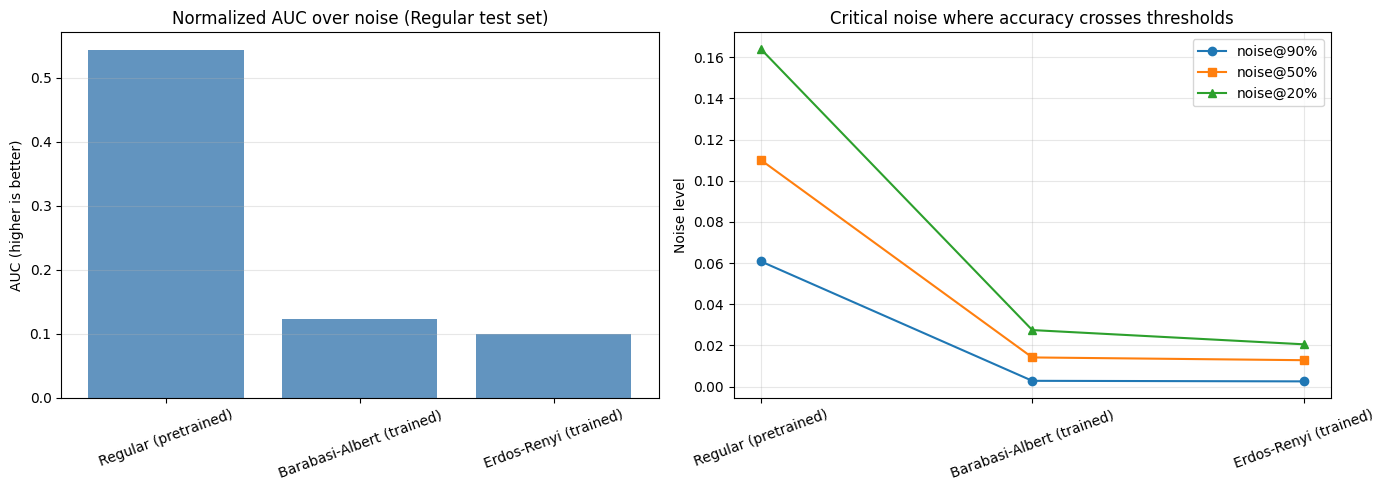

In [ ]:
# 10.1 Robustness summary: AUC + critical noise thresholds

if 'results_cross' not in globals():
    raise RuntimeError("Please run Section 9 first (cross-evaluation) to populate `results_cross`.")

curves_regular_test = {m: results_cross[m]['Regular'] for m in results_cross}
df_robust = summarize_curves(curves_regular_test, list_noise_cross)

print("Robustness summary (tested on Regular):")
display(df_robust.style.format({"AUC": "{:.3f}", "noise@90%": "{:.3f}", "noise@50%": "{:.3f}", "noise@20%": "{:.3f}"}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUC barplot
axes[0].bar(df_robust.index, df_robust['AUC'], color='steelblue', alpha=0.85)
axes[0].set_title('Normalized AUC over noise (Regular test set)')
axes[0].set_ylabel('AUC (higher is better)')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(True, axis='y', alpha=0.3)

# Critical thresholds
x = np.arange(len(df_robust.index))
axes[1].plot(x, df_robust['noise@90%'], marker='o', label='noise@90%')
axes[1].plot(x, df_robust['noise@50%'], marker='s', label='noise@50%')
axes[1].plot(x, df_robust['noise@20%'], marker='^', label='noise@20%')
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_robust.index, rotation=20)
axes[1].set_title('Critical noise where accuracy crosses thresholds')
axes[1].set_ylabel('Noise level')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

ID/OOD summary at noise=0.110
Absolute accuracy matrix:


Test graph type,Regular,Erdos-Renyi,Barabasi-Albert
Trained model,,,
Regular (pretrained),0.501,0.486,0.486
Erdos-Renyi (trained),0.038,0.212,0.306
Barabasi-Albert (trained),0.055,0.484,0.695


Relative retention matrix (OOD / ID):


Test graph type,Regular,Erdos-Renyi,Barabasi-Albert
Trained model,,,
Regular (pretrained),1.000,0.971,0.971
Erdos-Renyi (trained),0.179,1.000,1.444
Barabasi-Albert (trained),0.079,0.696,1.000


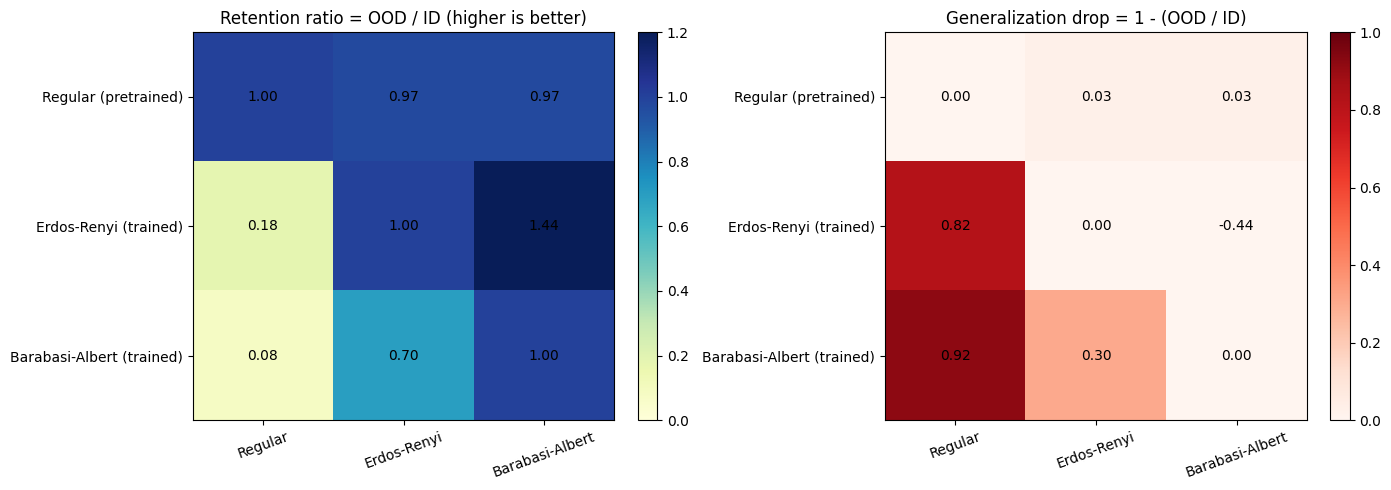

In [ ]:
# 10.2 In-distribution vs OOD gap heatmaps

if 'results_cross' not in globals():
    raise RuntimeError("Please run Section 9 first (cross-evaluation) to populate `results_cross`.")

noise_idx = int(np.argmin(np.abs(list_noise_cross - 0.11)))
noise_val = float(list_noise_cross[noise_idx])

id_label_map = {
    'Regular (pretrained)': 'Regular',
    'Erdos-Renyi (trained)': 'Erdos-Renyi',
    'Barabasi-Albert (trained)': 'Barabasi-Albert',
}

acc_mat = pd.DataFrame(
    {
        m: {lbl: results_cross[m][lbl][noise_idx] for lbl in test_graph_labels}
        for m in results_cross
    }
).T
acc_mat.index.name = 'Trained model'
acc_mat.columns.name = 'Test graph type'

ratio_mat = acc_mat.copy()
drop_mat = acc_mat.copy()
for m in acc_mat.index:
    id_acc = acc_mat.loc[m, id_label_map[m]]
    ratio_mat.loc[m] = acc_mat.loc[m] / (id_acc + 1e-12)
    drop_mat.loc[m] = 1.0 - ratio_mat.loc[m]

print(f"ID/OOD summary at noise={noise_val:.3f}")
print("Absolute accuracy matrix:")
display(acc_mat.style.format('{:.3f}'))
print("Relative retention matrix (OOD / ID):")
display(ratio_mat.style.format('{:.3f}'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(ratio_mat.values, cmap='YlGnBu', vmin=0, vmax=1.2, aspect='auto')
axes[0].set_title('Retention ratio = OOD / ID (higher is better)')
axes[0].set_xticks(range(len(ratio_mat.columns)))
axes[0].set_xticklabels(ratio_mat.columns, rotation=20)
axes[0].set_yticks(range(len(ratio_mat.index)))
axes[0].set_yticklabels(ratio_mat.index)
for i in range(ratio_mat.shape[0]):
    for j in range(ratio_mat.shape[1]):
        v = ratio_mat.values[i, j]
        axes[0].text(j, i, f'{v:.2f}', ha='center', va='center', color='black', fontsize=10)
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(drop_mat.values, cmap='Reds', vmin=0, vmax=1.0, aspect='auto')
axes[1].set_title('Generalization drop = 1 - (OOD / ID)')
axes[1].set_xticks(range(len(drop_mat.columns)))
axes[1].set_xticklabels(drop_mat.columns, rotation=20)
axes[1].set_yticks(range(len(drop_mat.index)))
axes[1].set_yticklabels(drop_mat.index)
for i in range(drop_mat.shape[0]):
    for j in range(drop_mat.shape[1]):
        v = drop_mat.values[i, j]
        axes[1].text(j, i, f'{v:.2f}', ha='center', va='center', color='black', fontsize=10)
plt.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

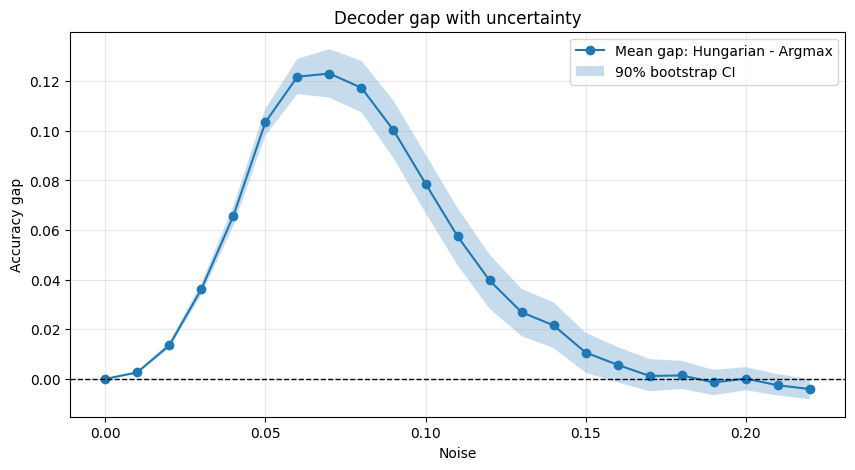

Paired permutation tests (H0: mean gap == 0)
  noise=0.04 | mean gap=0.0657 | p-value~0
  noise=0.08 | mean gap=0.1174 | p-value~0
  noise=0.12 | mean gap=0.0397 | p-value~0
  noise=0.16 | mean gap=0.0057 | p-value~0.1787


In [ ]:
# 10.3 Statistical uncertainty & significance: Hungarian vs Argmax

if ('all_a' not in globals()) or ('all_a_argmax' not in globals()):
    raise RuntimeError("Please run Sections 1 and 3 first to compute `all_a` and `all_a_argmax`.")

mean_gap = np.mean(all_a - all_a_argmax, axis=1)
ci_low = np.zeros_like(mean_gap)
ci_high = np.zeros_like(mean_gap)

for i in range(len(list_noise)):
    lo, hi = bootstrap_ci_mean(all_a[i] - all_a_argmax[i], n_boot=1500, alpha=0.10, seed=123 + i)
    ci_low[i] = lo
    ci_high[i] = hi

plt.figure(figsize=(10, 5))
plt.plot(list_noise, mean_gap, marker='o', label='Mean gap: Hungarian - Argmax')
plt.fill_between(list_noise, ci_low, ci_high, alpha=0.25, label='90% bootstrap CI')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Noise')
plt.ylabel('Accuracy gap')
plt.title('Decoder gap with uncertainty')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Lightweight paired permutation test at selected noise values
rng = np.random.default_rng(123)
selected_noises = [0.04, 0.08, 0.12, 0.16]
n_perm = 3000

print("Paired permutation tests (H0: mean gap == 0)")
for nz in selected_noises:
    idx = int(np.argmin(np.abs(list_noise - nz)))
    d = all_a[idx] - all_a_argmax[idx]
    obs = d.mean()

    signs = rng.choice([-1, 1], size=(n_perm, len(d)))
    perm_means = (signs * d).mean(axis=1)
    pval = np.mean(np.abs(perm_means) >= abs(obs))
    print(f"  noise={list_noise[idx]:.2f} | mean gap={obs:.4f} | p-value~{pval:.4g}")

Creating dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_120_20_1.0_0.02_0.2/test.pkl


100%|██████████| 120/120 [00:00<00:00, 1692.33it/s]


Saving dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_120_20_1.0_0.02_0.2/test.pkl
Creating dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_120_20_1.0_0.02_0.2/test_dgl.pkl
Converting data to DGL format


100%|██████████| 120/120 [00:00<00:00, 2424.10it/s]

Conversion ended.
Saving dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_120_20_1.0_0.02_0.2/test_dgl.pkl


...

Conversion ended.
Saving dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_120_100_1.0_0.14_0.2/test_dgl.pkl
Creating dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_120_100_1.0_0.2_0.2/test.pkl


100%|██████████| 120/120 [00:00<00:00, 207.46it/s]


Saving dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_120_100_1.0_0.2_0.2/test.pkl
Creating dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_120_100_1.0_0.2_0.2/test_dgl.pkl
Converting data to DGL format


100%|██████████| 120/120 [00:00<00:00, 492.63it/s]


Conversion ended.
Saving dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_120_100_1.0_0.2_0.2/test_dgl.pkl


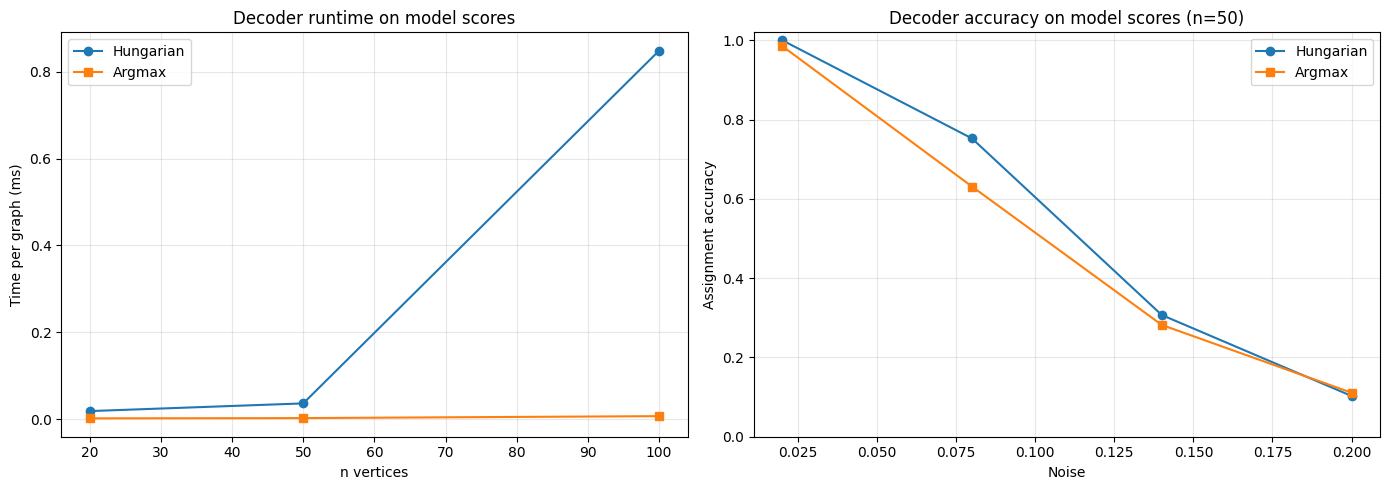

Runtime summary (ms):


decoder,Argmax,Hungarian,speedup(H/A)
n,,,
20,0.002,0.019,10.007
50,0.002,0.036,14.999
100,0.007,0.848,123.011


Accuracy summary at n=50:


decoder,Argmax,Hungarian
noise,,
0.020000,0.985,1.000
0.080000,0.631,0.752
0.140000,0.282,0.307
0.200000,0.111,0.103


In [ ]:
# 10.4 Decoder speed/accuracy trade-off 

if 'model' not in globals():
    raise RuntimeError("Please run model loading/inference cells first so `model` is available.")

sizes = [20, 50, 100]
noise_levels = [0.02, 0.08, 0.14, 0.20]
num_examples_eval = 120
n_ref = int(args['n_vertices'])  

runtime_records = []
acc_records_ref = []

model.eval()
with torch.no_grad():
    for n in sizes:
        for nz in noise_levels:
            args_loc = copy.deepcopy(args)
            args_loc['n_vertices'] = n
            args_loc['noise'] = float(nz)
            args_loc['num_examples_test'] = num_examples_eval

            gene = QAP_Generator('test', args_loc, path_dataset)
            gene.load_dataset()

            for i in range(num_examples_eval):
                data, _ = gene[i]
                score = model(data.unsqueeze(0).to(device))[0].cpu().numpy()  # (n, n)
                label = np.arange(score.shape[0])

                # Hungarian decode
                t0 = time.perf_counter()
                _, pred_h = linear_sum_assignment(-score)
                t1 = time.perf_counter()
                acc_h = np.mean(pred_h == label)

                # Argmax decode
                t2 = time.perf_counter()
                pred_a = np.argmax(score, axis=1)
                t3 = time.perf_counter()
                acc_a = np.mean(pred_a == label)

                runtime_records.append({'n': n, 'noise': nz, 'decoder': 'Hungarian', 'time_ms': (t1 - t0) * 1000})
                runtime_records.append({'n': n, 'noise': nz, 'decoder': 'Argmax', 'time_ms': (t3 - t2) * 1000})

                if n == n_ref:
                    acc_records_ref.append({'noise': nz, 'decoder': 'Hungarian', 'acc': acc_h})
                    acc_records_ref.append({'noise': nz, 'decoder': 'Argmax', 'acc': acc_a})


df_runtime = pd.DataFrame(runtime_records)
df_acc_ref = pd.DataFrame(acc_records_ref)

rt = df_runtime.groupby(['n', 'decoder'])['time_ms'].mean().reset_index()
ac = df_acc_ref.groupby(['noise', 'decoder'])['acc'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


for dec, mk in [('Hungarian', 'o'), ('Argmax', 's')]:
    cur = rt[rt['decoder'] == dec]
    axes[0].plot(cur['n'], cur['time_ms'], marker=mk, label=dec)
axes[0].set_title('Decoder runtime on model scores')
axes[0].set_xlabel('n vertices')
axes[0].set_ylabel('Time per graph (ms)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Accuracy vs noise plot 
for dec, mk in [('Hungarian', 'o'), ('Argmax', 's')]:
    cur = ac[ac['decoder'] == dec]
    axes[1].plot(cur['noise'], cur['acc'], marker=mk, label=dec)
axes[1].set_title(f'Decoder accuracy on model scores (n={n_ref})')
axes[1].set_xlabel('Noise')
axes[1].set_ylabel('Assignment accuracy')
axes[1].set_ylim(0, 1.02)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

pivot_rt = rt.pivot(index='n', columns='decoder', values='time_ms')
if {'Hungarian', 'Argmax'}.issubset(set(pivot_rt.columns)):
    pivot_rt['speedup(H/A)'] = pivot_rt['Hungarian'] / pivot_rt['Argmax']
print('Runtime summary (ms):')
display(pivot_rt.style.format('{:.3f}'))

print(f'Accuracy summary at n={n_ref}:')
display(ac.pivot(index='noise', columns='decoder', values='acc').style.format('{:.3f}'))

Creating dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_200_20_1.0_0.0_0.2/test.pkl


100%|██████████| 200/200 [00:00<00:00, 3139.27it/s]


Saving dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_200_20_1.0_0.0_0.2/test.pkl
Creating dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_200_20_1.0_0.0_0.2/test_dgl.pkl
Converting data to DGL format


100%|██████████| 200/200 [00:00<00:00, 3055.36it/s]

Conversion ended.
Saving dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_200_20_1.0_0.0_0.2/test_dgl.pkl


...

Conversion ended.
Saving dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_200_100_1.0_0.18_0.2/test_dgl.pkl
Creating dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_200_150_1.0_0.18_0.2/test.pkl


100%|██████████| 200/200 [00:01<00:00, 111.03it/s]


Saving dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_200_150_1.0_0.18_0.2/test.pkl
Creating dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_200_150_1.0_0.18_0.2/test_dgl.pkl
Converting data to DGL format


100%|██████████| 200/200 [00:00<00:00, 293.75it/s]


Conversion ended.
Saving dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_200_150_1.0_0.18_0.2/test_dgl.pkl


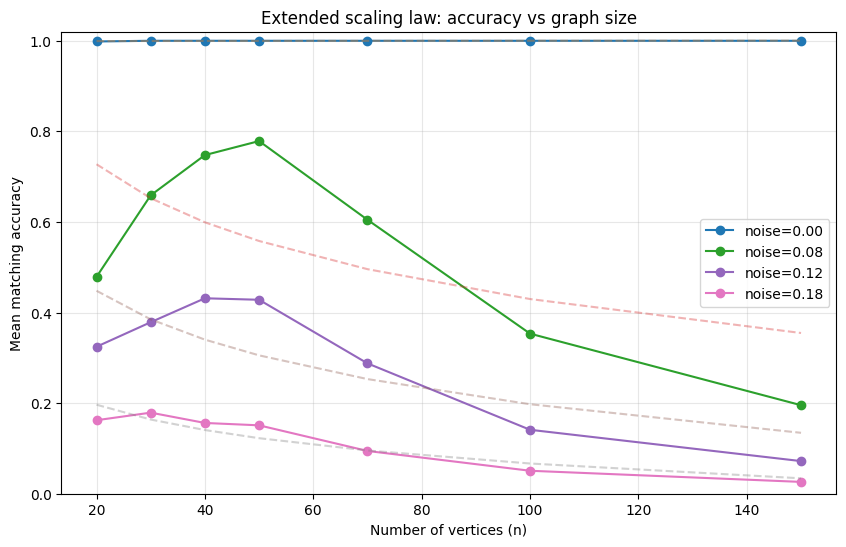

Scaling summary:


,noise=0.00,noise=0.08,noise=0.12,noise=0.18
n_vertices,,,,
20,0.998,0.479,0.325,0.162
30,1.000,0.659,0.379,0.179
40,1.000,0.748,0.432,0.156
50,1.000,0.779,0.428,0.151
70,1.000,0.605,0.288,0.094
100,1.000,0.353,0.141,0.051
150,1.000,0.195,0.072,0.026


In [ ]:
# 10.5 Scaling-law analysis across graph sizes

if 'model' not in globals():
    raise RuntimeError("Please run model loading/inference cells first so `model` is available.")

sizes_ext = [20, 30, 40, 50, 70, 100, 150]
noises_ext = [0.00, 0.08, 0.12, 0.18]
num_examples_ext = 200

acc_by_noise = {nz: [] for nz in noises_ext}

model.eval()
with torch.no_grad():
    for nz in noises_ext:
        for n in sizes_ext:
            args_sz = copy.deepcopy(args)
            args_sz['n_vertices'] = int(n)
            args_sz['noise'] = float(nz)
            args_sz['num_examples_test'] = int(num_examples_ext)

            gene = QAP_Generator('test', args_sz, path_dataset)
            gene.load_dataset()
            loader = siamese_loader(gene, 50, gene.constant_n_vertices)

            _, all_acc_local = all_losses_acc(
                loader,
                model,
                criterion,
                device,
                eval_score=accuracy_linear_assignment,
            )
            acc_by_noise[nz].append(all_acc_local.mean())

plt.figure(figsize=(10, 6))
for nz in noises_ext:
    y = np.array(acc_by_noise[nz])
    plt.plot(sizes_ext, y, marker='o', label=f'noise={nz:.2f}')

    x = np.log(np.array(sizes_ext))
    coef = np.polyfit(x, y, deg=1)
    y_fit = coef[0] * x + coef[1]
    plt.plot(sizes_ext, y_fit, linestyle='--', alpha=0.35)

plt.xlabel('Number of vertices (n)')
plt.ylabel('Mean matching accuracy')
plt.title('Extended scaling law: accuracy vs graph size')
plt.ylim(0, 1.02)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Summary table
df_scaling = pd.DataFrame(acc_by_noise, index=sizes_ext)
df_scaling.index.name = 'n_vertices'
df_scaling.columns = [f'noise={c:.2f}' for c in df_scaling.columns]
print('Scaling summary:')
display(df_scaling.style.format('{:.3f}'))